In [ ]:
!nvidia-smi


Mon Mar  2 22:47:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import pandas as pd
import os
import time
import json 
import warnings
from scipy.stats import t as t_dist
from arch import arch_model
import yfinance as yf

In [3]:
random_seed=(42)

stock_prices=pd.read_csv("GARCH.csv",  delimiter=",")

Connect to Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [5]:
import os
os.listdir("/content/drive/MyDrive")

['german ppt - 복사본.pptx',
 'german',
 'Scanned_20180125-1718.pdf',
 'Scanned_20180125-1722.pdf',
 'Scanned_20180125-1723 (1).pdf',
 'Scanned_20180125-1723.pdf',
 'Scanned_20180126-0951.pdf',
 'Scanned_20180126-0952.pdf',
 'Scanned_20180207-1634.pdf',
 'Scanned_20180207-1635.pdf',
 'Donguk Song-PT ocean enneagram.gdoc',
 'Scanned_20180410-1826.pdf',
 'Ich mochte ein(en) Diplomat werden.gdoc',
 'Was mochtest du werden?.gslides',
 'Untitled document (2).gdoc',
 'Untitled presentation.gslides',
 'Call recording Kevin_180420_153416 (1).m4a',
 'Call recording Kevin_180420_153416.m4a',
 'Play Books Notes',
 'korean refugee 3',
 'korean refugee 1',
 'korean refugee speaking',
 'korean refugee 2',
 'jerry',
 'IMG_0436.JPG',
 'official transcript.pdf',
 'Copy of official transcript.pdf',
 'EPQ form.docx',
 'Investment Bussiness Plan by Slidesgo의 사본.gslides',
 '제목 없는 프레젠테이션 (1).gslides',
 'manchester maths stats.gslides',
 'City, London.gslides',
 'Edinburgh.gslides',
 'MO

Data Import

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Statistical Challenge 2026/black_scholes_simulation_data_T5_with_price.csv")

In [5]:
df = pd.read_csv("black_scholes_simulation_data_T5_with_price.csv", delimiter = ",")


In [6]:
df = df[df['day'] >= 0]
df = df.reset_index(drop = True)



In [27]:
df['bs_price_lag'] = df.groupby('simulation')['bs_price'].shift(1)
df = df.dropna(subset=['bs_price_lag']).reset_index(drop=True)

In [7]:
df.shape

(10090000, 8)

In [8]:
df = df[df["T"]>1]

In [9]:
import os
# Delete old cached sequences so they get rebuilt with the fast method
for f in os.listdir('.'):
    if f.endswith('_X.npy') or f.endswith('_y.npy'):
        os.remove(f)
        print(f"Deleted {f}")

Deleted seq_test_y.npy
Deleted seq_test_X.npy
Deleted seq_lag_X.npy
Deleted seq_lag_y.npy


LSTM training Code

In [9]:

#LSTM training function + hyperparameter tuning

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


def build_sequences(df, seq_len, features, cache_prefix):
    """Vectorized sliding-window sequences, chunked to avoid OOM."""
    xf, yf = f'{cache_prefix}_X.npy', f'{cache_prefix}_y.npy'
    if os.path.exists(xf):
        print("Loading cached sequences...")
        return np.load(xf), np.load(yf)

    df = df.sort_values(['simulation', 'day']).reset_index(drop=True)
    sims = df['simulation'].unique()
    n_sims = len(sims)
    dps = len(df) // n_sims
    nf = len(features)
    sps = dps - seq_len

    total = n_sims * sps
    print(f"Building {total:,} sequences "
          f"({n_sims} sims × {sps} windows of length {seq_len})...")

    feat = df[features].values.astype(np.float32)
    tgt  = df['bs_price'].values.astype(np.float32)

    # Sliding window index template (reused for every chunk)
    win_idx = np.arange(seq_len)[None, :] + np.arange(sps)[:, None]  # (sps, seq_len)

    # Pre-allocate output arrays on disk via memmap to avoid RAM spike
    X = np.lib.format.open_memmap(xf, mode='w+', dtype=np.float32,
                                   shape=(total, seq_len, nf))
    y = np.lib.format.open_memmap(yf, mode='w+', dtype=np.float32,
                                   shape=(total,))

    chunk_size = 200  # process 200 simulations at a time
    for start in range(0, n_sims, chunk_size):
        end = min(start + chunk_size, n_sims)
        n_chunk = end - start

        # Extract chunk of simulations
        f_chunk = feat[start * dps : end * dps].reshape(n_chunk, dps, nf)
        t_chunk = tgt[start * dps : end * dps].reshape(n_chunk, dps)

        X_chunk = f_chunk[:, win_idx, :]   # (n_chunk, sps, seq_len, nf)
        y_chunk = t_chunk[:, seq_len:]     # (n_chunk, sps)

        out_start = start * sps
        out_end   = out_start + n_chunk * sps
        X[out_start:out_end] = X_chunk.reshape(-1, seq_len, nf)
        y[out_start:out_end] = y_chunk.reshape(-1)

        print(f"  Processed sims {start}–{end-1}")

    # Flush to disk and reload as regular arrays
    del X, y
    X = np.load(xf)
    y = np.load(yf)
    print(f"Done: X={X.shape}, y={y.shape}")
    return X, y


def make_model(input_size, hidden, layers, drop, fc_sizes):
    """Simple LSTM → FC head."""
    class M(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True,
                                dropout=drop if layers > 1 else 0)
            mods = []
            prev = hidden
            for sz in fc_sizes:
                mods += [nn.Linear(prev, sz), nn.ReLU(), nn.Dropout(drop)]; prev = sz
            mods.append(nn.Linear(prev, 1))
            self.head = nn.Sequential(*mods)
            for n, p in self.lstm.named_parameters():
                nn.init.xavier_uniform_(p) if 'weight' in n else nn.init.zeros_(p)
            for m in self.head:
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        def forward(self, x):
            o, _ = self.lstm(x)
            out = self.head(o[:, -1, :]).squeeze(-1)
            return out
          
    return M()


def train_lstm(df, *, seq_len=50, features=('S','sigma','T','K',"r"),
               train_split=.7, val_split=.15,
               hidden=128, layers=3, drop=.2, fc=(64,),
               bs=256, lr=1e-3, epochs=50, patience=10, wd=1e-5, clip=1.0,
               seed=42, save_dir='lstm_out', cache='seq', loss_fn = 'mse'):
    """
    Full pipeline: sequences → scale → train → evaluate → plots.
    Returns (model, history_dict, metrics_dict, scalers_dict).
    """
    torch.manual_seed(seed); np.random.seed(seed)
    os.makedirs(save_dir, exist_ok=True)
    features = list(features); nf = len(features)

    # --- sequences ---
    X, y = build_sequences(df, seq_len, features, cache)

    # --- split by simulation ---
    n_sims = df['simulation'].nunique()
    sps = len(X) // n_sims
    tr = int(train_split * n_sims) * sps
    va = int(val_split  * n_sims) * sps
    Xtr, ytr = X[:tr], y[:tr]
    Xva, yva = X[tr:tr+va], y[tr:tr+va]
    Xte, yte = X[tr+va:], y[tr+va:]
    print(f"  Split: train={len(Xtr):,}  val={len(Xva):,}  test={len(Xte):,}")

    # --- scale ---
    sx = StandardScaler()
    Xtr_s = sx.fit_transform(Xtr.reshape(-1,nf)).reshape(Xtr.shape)
    Xva_s = sx.transform(Xva.reshape(-1,nf)).reshape(Xva.shape)
    Xte_s = sx.transform(Xte.reshape(-1,nf)).reshape(Xte.shape)
    sy = StandardScaler()
    ytr_s = sy.fit_transform(ytr.reshape(-1,1)).ravel()
    yva_s = sy.transform(yva.reshape(-1,1)).ravel()
    yte_s = sy.transform(yte.reshape(-1,1)).ravel()

    pin = torch.cuda.is_available()
    mk = lambda X, y, shuf: DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)), bs, shuffle=shuf, pin_memory=pin)
    trl, val, tel = mk(Xtr_s, ytr_s, True), mk(Xva_s, yva_s, False), mk(Xte_s, yte_s, False)

    # --- model ---
    model = make_model(nf, hidden, layers, drop, list(fc)).to(device)
    if loss_fn == 'mse':
        crit = nn.MSELoss()
    elif loss_fn == 'huber':
        crit = nn.HuberLoss(delta=1.0)
    elif loss_fn == 'huber_05':
        crit = nn.HuberLoss(delta=0.5)
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=.5, patience=5, min_lr=1e-7)
    npar = sum(p.numel() for p in model.parameters())
    print(f"  Model: hidden={hidden} layers={layers} drop={drop} fc={list(fc)} params={npar:,}")

    # --- train ---
    hist = {'train':[], 'val':[], 'lr':[]}
    best_vl, wait, best_w = float('inf'), 0, None
    print(f"  {'Ep':<4} {'Train':<11} {'Val':<11} {'LR':<13} Status")

    for ep in range(1, epochs+1):
        # train
        model.train(); tot, n = 0, 0
        for bx, by in tqdm(trl, leave=False, desc='train'):
            bx, by = bx.to(device), by.to(device)
            opt.zero_grad(); loss = crit(model(bx), by); loss.backward()
            if clip: torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step(); tot += loss.item(); n += 1
        tl = tot / n
        # val
        model.eval(); tot, n = 0, 0
        with torch.no_grad():
            for bx, by in tqdm(val, leave=False, desc='val'):
                tot += crit(model(bx.to(device)), by.to(device)).item(); n += 1
        vl = tot / n
        hist['train'].append(tl); hist['val'].append(vl)
        hist['lr'].append(opt.param_groups[0]['lr'])
        sched.step(vl)
        if vl < best_vl:
            best_vl, wait = vl, 0; best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_w, f'{save_dir}/best.pth'); s = '✓'
        else:
            wait += 1; s = f'wait {wait}/{patience}'
        print(f"  {ep:<4} {tl:<11.6f} {vl:<11.6f} {opt.param_groups[0]['lr']:<13.2e} {s}")
        if wait >= patience: print('  Early stop'); break

    if best_w: model.load_state_dict(best_w)

    # --- evaluate ---
    model.eval(); preds, acts = [], []
    with torch.no_grad():
        for bx, by in tqdm(tel, leave=False, desc='test'):
            preds.extend(model(bx.to(device)).cpu().numpy()); acts.extend(by.numpy())
    yt = sy.inverse_transform(np.array(acts).reshape(-1,1)).ravel()
    yp = sy.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
    yp = np.clip(yp, 0, None)
    mse = mean_squared_error(yt, yp); mask = yt != 0
    met = {'wMAPE':  np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt)) * 100,
           'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(yt, yp)
            }
    print(f"\n  TEST   wMAPE={met['wMAPE']:.1f}  RMSE={met['RMSE']:.1f}")

    # --- plots ---
    fig, ax = plt.subplots(1,2,figsize=(13,4))
    ax[0].plot(hist['train'],label='train'); ax[0].plot(hist['val'],label='val')
    ax[0].set(xlabel='Epoch',ylabel='Loss',title='Loss'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist['lr'],c='green'); ax[1].set(xlabel='Epoch',ylabel='LR',title='LR',yscale='log'); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{save_dir}/loss.png',dpi=150); plt.show()

    fig, ax = plt.subplots(1,2,figsize=(13,5))
    idx = np.random.choice(len(yt), min(1000,len(yt)), replace=False)
    ax[0].scatter(yt[idx],yp[idx],s=8,alpha=.4)
    ax[0].plot([yt.min(),yt.max()],[yt.min(),yt.max()],'r--')
    ax[0].set(xlabel='True',ylabel='Pred',title='Pred vs True'); ax[0].grid(alpha=.3)
    ax[1].hist(yp-yt,bins=50,alpha=.7,ec='k'); ax[1].axvline(0,c='r',ls='--')
    ax[1].set(xlabel='Error',ylabel='Freq',title='Errors'); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'{save_dir}/preds.png',dpi=150); plt.show()
    
    return model, hist, met, {'sx':sx, 'sy':sy}

ModuleNotFoundError: No module named 'torch'

Smaller Traning Data with extra variables

In [11]:
# ── Do the heavy operations on df_small directly, not full df ──

# First, filter down to reduce memory
df_small = df[df['simulation'] < 1500].copy()
df_small = df_small.sort_values(['simulation', 'day']).reset_index(drop=True)

# Lightweight features (these are fine on full df or small)
df_small['moneyness'] = df_small['S'] / df_small['K']
df_small['log_moneyness'] = np.log(df_small['S'] / df_small['K'])
df_small['intrinsic'] = np.maximum(df_small['S'] - df_small['K'], 0)

# Daily changes
df_small['dS'] = df_small.groupby('simulation')['S'].diff()
df_small['dsigma'] = df_small.groupby('simulation')['sigma'].diff()
df_small['dr'] = df_small.groupby('simulation')['r'].diff()
df_small['log_return'] = df_small.groupby('simulation')['S'].transform(
    lambda x: np.log(x / x.shift(1))
)

# BS analytical terms
df_small['sqrt_T'] = np.sqrt(np.maximum(df_small['T'], 1e-8))
df_small['sigma_sqrt_T'] = df_small['sigma'] * df_small['sqrt_T']
df_small['d1'] = (df_small['log_moneyness'] + (df_small['r'] + 0.5 * df_small['sigma']**2) * df_small['T']) / (
    df_small['sigma_sqrt_T'].replace(0, 1e-8)
)
df_small['d2'] = df_small['d1'] - df_small['sigma_sqrt_T']
df_small['discount'] = np.exp(-df_small['r'] * df_small['T'])

# Rolling stats — do ONE window at a time and gc.collect between
import gc

for window in [5, 20]:
    df_small[f'S_ma_{window}'] = df_small.groupby('simulation')['S'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df_small[f'sigma_ma_{window}'] = df_small.groupby('simulation')['sigma'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    gc.collect()

df_small['S_rel_ma5'] = df_small['S'] / df_small['S_ma_5']

# Cross features
df_small['S_sigma'] = df_small['S'] * df_small['sigma']
df_small['K_discount'] = df_small['K'] * df_small['discount']

# Clean NaNs
df_small = df_small.dropna().reset_index(drop=True)

print(f"Shape: {df_small.shape}")

Shape: (1512000, 27)


Feature Combination

In [12]:

# Combination 1: Original + moneyness features
feat_v1 = ('S', 'sigma', 'T', 'K', 'r', 'moneyness', 'log_moneyness', 'intrinsic')

# Combination 2: Add daily changes
feat_v2 = ('S', 'sigma', 'T', 'K', 'r', 'moneyness', 'intrinsic', 'dS', 'dsigma', 'log_return')

# Combination 3: Add rolling stats
feat_v3 = ('S', 'sigma', 'T', 'K', 'r', 'moneyness', 'intrinsic',
           'dS', 'dsigma', 'S_ma_5', 'S_ma_20', 'sigma_ma_5', 'S_std_5')

# Combination 4: Add BS analytical terms
feat_v4 = ('S', 'sigma', 'T', 'K', 'r', 'moneyness', 'intrinsic',
           'dS', 'dsigma', 'd1', 'd2', 'discount', 'sigma_sqrt_T')

# Combination 5: Kitchen sink
feat_v5 = ('S', 'sigma', 'T', 'K', 'r', 'moneyness', 'log_moneyness', 'intrinsic',
           'dS', 'dsigma', 'log_return', 'S_ma_5', 'S_ma_20', 'sigma_ma_5',
           'S_std_5', 'S_rel_ma5', 'd1', 'd2', 'discount', 'sigma_sqrt_T')


Building 1,437,000 sequences (1500 sims × 958 windows of length 50)...


KeyboardInterrupt: 

Model performance by Feature Combination

In [ ]:
#model V1
model_v1, hist_v1, met_v1, scalers_v1 = train_lstm(
    df_small, features=feat_v1,
    hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_v1', cache='seq_v1'
)

In [ ]:
#model V2
model_v2, hist_v2, met_v2, scalers_v2 = train_lstm(
    df_small, features=feat_v2,
    hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_v2', cache='seq_v2'
)

In [ ]:
#model V3
model_v3, hist_v3, met_v3, scalers_v3 = train_lstm(
    df_small, features=feat_v3,
    hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_v3', cache='seq_v3'
)

In [ ]:
#model V4
model_v4, hist_v4, met_v4, scalers_v4 = train_lstm(
    df_small, features=feat_v4,
    hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_v4', cache='seq_v4'
)

In [ ]:
#model V5
model_v5, hist_v5, met_v5, scalers_v5 = train_lstm(
    df_small, features=feat_v5,
    hidden=64, layers=2, fc=(32,),
    bs=512, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_v5', cache='seq_v5')

In [33]:
df_small.shape

(1008000, 9)

Basic Model with the original variables

Building 958,000 sequences (1000 sims × 958 windows of length 50)...
  Processed sims 0–199
  Processed sims 200–399
  Processed sims 400–599
  Processed sims 600–799
  Processed sims 800–999
Done: X=(958000, 50, 5), y=(958000,)
  Split: train=670,600  val=143,700  test=143,700
  Model: hidden=64 layers=2 drop=0.2 fc=[32] params=53,569
  Ep   Train       Val         LR            Status


  1    0.028030    0.003110    1.00e-03      ✓


  2    0.020575    0.002583    1.00e-03      ✓


  3    0.019862    0.002772    1.00e-03      wait 1/10


  4    0.019798    0.003540    1.00e-03      wait 2/10


...

  47   0.017429    0.002002    6.25e-05      wait 7/10


  48   0.017432    0.001809    6.25e-05      wait 8/10


  49   0.017221    0.002094    6.25e-05      wait 9/10


  50   0.017434    0.002109    6.25e-05      wait 10/10
  Early stop



  TEST   wMAPE=2.3  RMSE=136.8


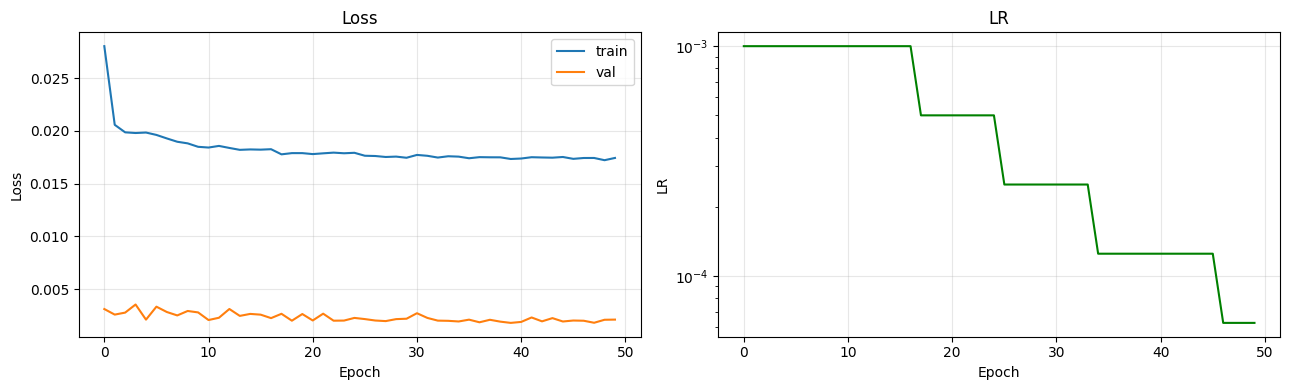

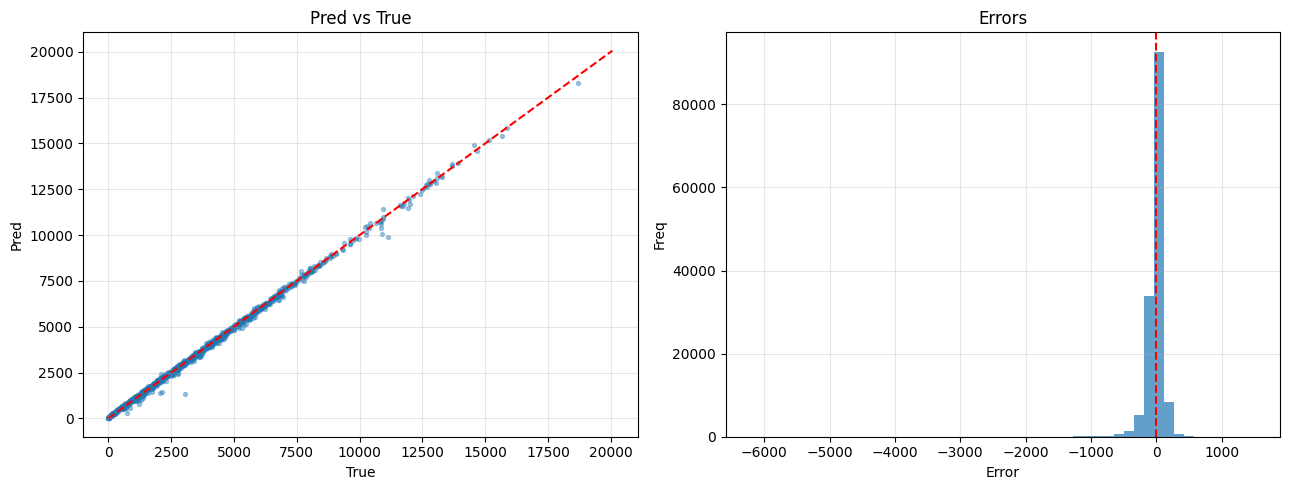

In [16]:
model, hist, met, scalers = train_lstm(
    df_small, hidden=64, layers=2, fc=(32,),
    bs=256, lr=1e-3, epochs=50,patience=10,
    save_dir='lstm_test', cache='seq_test')

Model with today's price

Loading cached sequences...
  Split: train=670,600  val=143,700  test=143,700
  Model: hidden=64 layers=2 drop=0.2 fc=[32] params=53,825
  Ep   Train       Val         LR            Status


  1    0.026344    0.003100    1.00e-03      ✓


  2    0.019166    0.002663    1.00e-03      ✓


  3    0.018394    0.002458    1.00e-03      ✓


  4    0.018191    0.002324    1.00e-03      ✓


...

  29   0.017234    0.001920    2.50e-04      wait 12/15


  30   0.016974    0.002449    2.50e-04      wait 13/15


  31   0.016912    0.002224    2.50e-04      wait 14/15


  32   0.017008    0.001997    2.50e-04      wait 15/15
  Early stop



  TEST   wMAPE=2.4  RMSE=140.6


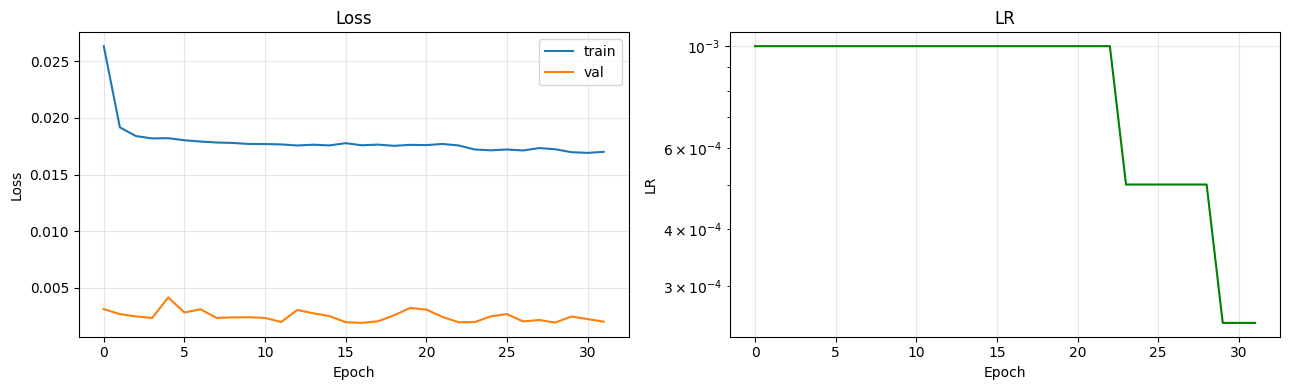

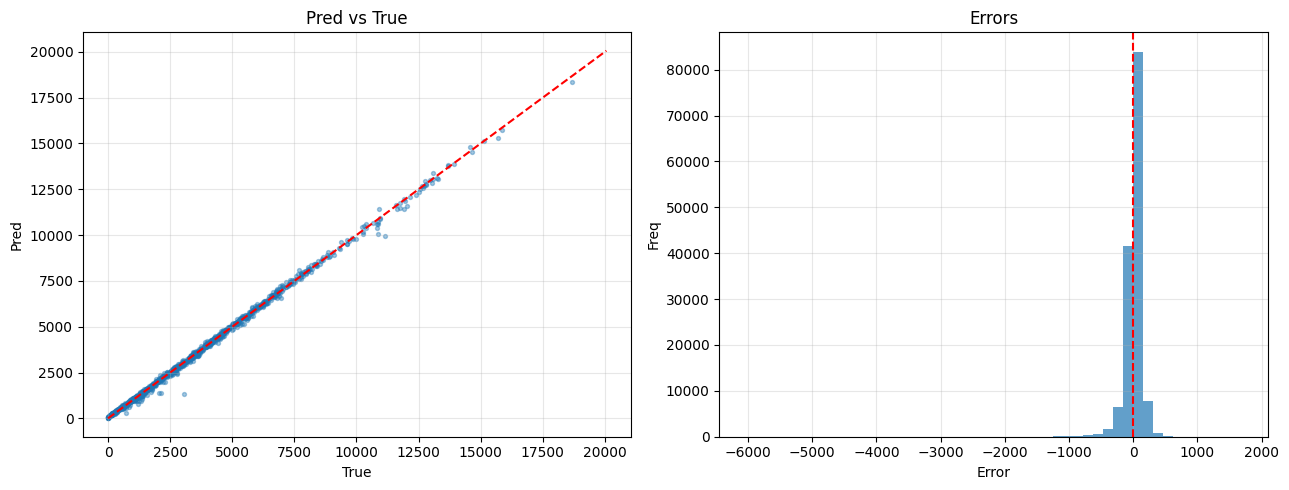

In [35]:
model_b, hist_b, met_b, scalers_b = train_lstm(
    df_small,
    features=('S', 'sigma', 'T', 'K', 'r', 'bs_price_lag'),
    hidden=64, layers=2, fc=(32,),
    bs=256, lr=1e-3, epochs=80, patience=15,
    save_dir='lstm_with_lag', cache='seq_lag'
)

Sensitivity Analysis

In [19]:
import gc
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from scipy.stats import norm

gc.collect()
torch.cuda.empty_cache()

# ── 1. Build sequences from unseen data ──
df_unseen = df[df['simulation'] >= 1000].copy()
df_unseen = df_unseen[df_unseen['day'] >= 0].reset_index(drop=True)

seq_len = 50
features = ['S', 'sigma', 'T', 'K', 'r']
nf = len(features)

df_unseen = df_unseen.sort_values(['simulation', 'day']).reset_index(drop=True)
sims = df_unseen['simulation'].unique()
n_sims = len(sims)
dps = len(df_unseen) // n_sims

# Build sequences in chunks to save memory
# Only keep ~2000 simulations max to avoid crashes
max_sims = 1000

feat = df_unseen[features].values.astype(np.float32)
tgt = df_unseen['bs_price'].values.astype(np.float32)

X_list, y_list, last_feats = [], [], []

for s in tqdm(range(max_sims), desc="Building sequences"):
    off = s * dps
    sf = feat[off:off + dps]
    st = tgt[off:off + dps]
    for i in range(seq_len, dps):
        X_list.append(sf[i - seq_len:i])
        y_list.append(st[i])
        last_feats.append(sf[i])  # the actual feature values at prediction point

X_test = np.array(X_list, dtype=np.float32)
y_true = np.array(y_list, dtype=np.float32)
last_feats = np.array(last_feats, dtype=np.float32)

del X_list, y_list
gc.collect()
print(f"Test sequences: {len(X_test):,}")

Building sequences: 100%|██████████| 1000/1000 [00:00<00:00, 1335.26it/s]


Test sequences: 958,000


In [20]:
# ── 2. Scale and predict ──
sx, sy = scalers['sx'], scalers['sy']

model.eval()
preds = []
batch_size = 512

for i in tqdm(range(0, len(X_test), batch_size), desc="Predicting"):
    end = min(i + batch_size, len(X_test))
    batch = X_test[i:end]
    batch_s = sx.transform(batch.reshape(-1, nf)).reshape(batch.shape)
    with torch.no_grad():
        p = model(torch.tensor(batch_s).to(device))
        preds.append(p.cpu().numpy())

preds = np.concatenate(preds)
y_pred = sy.inverse_transform(preds.reshape(-1, 1)).ravel()
y_pred = np.clip(y_pred, 0, None)

# Build test DataFrame
test_df = pd.DataFrame(last_feats, columns=features)
test_df['y_true'] = y_true
test_df['y_pred'] = y_pred
test_df['error'] = y_pred - y_true
test_df['abs_error'] = np.abs(test_df['error'])
test_df['moneyness'] = test_df['S'] / test_df['K']

print(f"\nOverall RMSE: {np.sqrt(np.mean(test_df['error']**2)):.4f}")
print(f"Overall wMAPE: {test_df['abs_error'].sum() / test_df['y_true'].abs().sum() * 100:.2f}%")

Predicting: 100%|██████████| 1872/1872 [00:07<00:00, 253.86it/s]


Overall RMSE: 132.1280
Overall wMAPE: 2.34%


In [21]:
# ── 3. Stratified wMAPE by moneyness ──
bins = [0, 0.75, 0.90, 0.95, 1.05, 1.10, 1.25, float('inf')]
labels = ['Deep OTM', 'OTM', 'Near OTM', 'ATM', 'Near ITM', 'ITM', 'Deep ITM']
test_df['m_bucket'] = pd.cut(test_df['moneyness'], bins=bins, labels=labels)

print("\n=== STRATIFIED BY MONEYNESS ===")
for label in labels:
    sub = test_df[test_df['m_bucket'] == label]
    if len(sub) == 0:
        continue
    rmse = np.sqrt(np.mean(sub['error']**2))
    wmape = sub['abs_error'].sum() / sub['y_true'].abs().sum() * 100
    mae = sub['abs_error'].mean()
    print(f"  {label:12s}  n={len(sub):>7,}  RMSE={rmse:>8.2f}  wMAPE={wmape:>6.2f}%  MAE={mae:>8.2f}")


=== STRATIFIED BY MONEYNESS ===
  Deep OTM      n= 73,449  RMSE=   89.72  wMAPE= 29.33%  MAE=   56.57
  OTM           n=114,270  RMSE=  119.44  wMAPE= 12.84%  MAE=   78.60
  Near OTM      n= 42,573  RMSE=  137.91  wMAPE=  8.57%  MAE=   85.49
  ATM           n= 89,587  RMSE=  131.31  wMAPE=  6.22%  MAE=   83.29
  Near ITM      n= 43,213  RMSE=  126.36  wMAPE=  4.44%  MAE=   78.57
  ITM           n=121,283  RMSE=  128.53  wMAPE=  3.14%  MAE=   75.00
  Deep ITM      n=473,625  RMSE=  141.29  wMAPE=  1.52%  MAE=   87.06


In [22]:
# ── 4. Stratified by maturity ──
bins_t = [0, 1, 2, 3, 4, float('inf')]
labels_t = ['T<1yr', '1-2yr', '2-3yr', '3-4yr', 'T>4yr']
test_df['t_bucket'] = pd.cut(test_df['T'], bins=bins_t, labels=labels_t)

print("\n=== STRATIFIED BY MATURITY ===")
for label in labels_t:
    sub = test_df[test_df['t_bucket'] == label]
    if len(sub) == 0:
        continue
    rmse = np.sqrt(np.mean(sub['error']**2))
    wmape = sub['abs_error'].sum() / sub['y_true'].abs().sum() * 100
    print(f"  {label:8s}  n={len(sub):>7,}  RMSE={rmse:>8.2f}  wMAPE={wmape:>6.2f}%")


=== STRATIFIED BY MATURITY ===
  1-2yr     n=252,000  RMSE=  140.33  wMAPE=  1.90%
  2-3yr     n=252,000  RMSE=  131.42  wMAPE=  2.17%
  3-4yr     n=252,000  RMSE=  127.31  wMAPE=  2.67%
  T>4yr     n=202,000  RMSE=  128.30  wMAPE=  3.29%


In [23]:
# ── 5. Stratified by volatility ──
test_df['vol_bucket'] = pd.qcut(test_df['sigma'], q=5,
                                 labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                                 duplicates='drop')

print("\n=== STRATIFIED BY VOLATILITY ===")
for label in ['Very Low', 'Low', 'Medium', 'High', 'Very High']:
    sub = test_df[test_df['vol_bucket'] == label]
    if len(sub) == 0:
        continue
    rmse = np.sqrt(np.mean(sub['error']**2))
    wmape = sub['abs_error'].sum() / sub['y_true'].abs().sum() * 100
    print(f"  {label:10s}  n={len(sub):>7,}  RMSE={rmse:>8.2f}  wMAPE={wmape:>6.2f}%")


=== STRATIFIED BY VOLATILITY ===
  Very Low    n=191,600  RMSE=   57.53  wMAPE=  1.43%
  Low         n=191,600  RMSE=   69.78  wMAPE=  1.70%
  Medium      n=191,600  RMSE=   83.92  wMAPE=  1.98%
  High        n=191,600  RMSE=  108.18  wMAPE=  2.42%
  Very High   n=191,600  RMSE=  245.69  wMAPE=  3.95%


/tmp/ipykernel_25676/3678771175.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  money_data = test_df.groupby('m_bucket').apply(
/tmp/ipykernel_25676/3678771175.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  money_data = test_df.groupby('m_bucket').apply(
/tmp/ipykernel_25676/3678771175.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default 

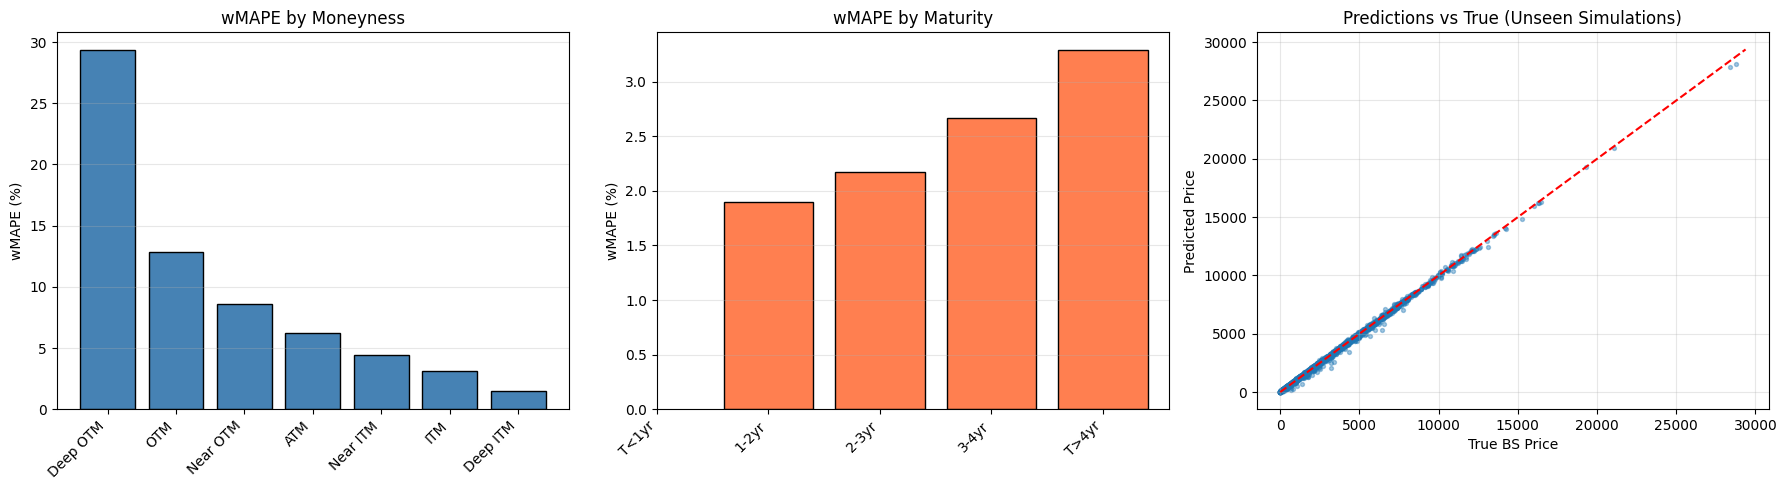

In [24]:
# ── 6. Plots ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Moneyness bar chart
money_data = test_df.groupby('m_bucket').apply(
    lambda x: x['abs_error'].sum() / x['y_true'].abs().sum() * 100
)
axes[0].bar(range(len(money_data)), money_data.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(money_data)))
axes[0].set_xticklabels(money_data.index, rotation=45, ha='right')
axes[0].set_ylabel('wMAPE (%)')
axes[0].set_title('wMAPE by Moneyness')
axes[0].grid(axis='y', alpha=0.3)

# Maturity bar chart
mat_data = test_df.groupby('t_bucket').apply(
    lambda x: x['abs_error'].sum() / x['y_true'].abs().sum() * 100
)
axes[1].bar(range(len(mat_data)), mat_data.values, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(mat_data)))
axes[1].set_xticklabels(mat_data.index, rotation=45, ha='right')
axes[1].set_ylabel('wMAPE (%)')
axes[1].set_title('wMAPE by Maturity')
axes[1].grid(axis='y', alpha=0.3)

# Pred vs True scatter
idx = np.random.choice(len(test_df), min(2000, len(test_df)), replace=False)
axes[2].scatter(test_df['y_true'].iloc[idx], test_df['y_pred'].iloc[idx], s=8, alpha=0.4)
axes[2].plot([test_df['y_true'].min(), test_df['y_true'].max()],
             [test_df['y_true'].min(), test_df['y_true'].max()], 'r--')
axes[2].set_xlabel('True BS Price')
axes[2].set_ylabel('Predicted Price')
axes[2].set_title('Predictions vs True (Unseen Simulations)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sensitivity_results/stratified_unseen.png', dpi=150)
plt.show()

Comparison to Naive Model

In [25]:
# ── 7. Naive Baseline Comparison ──

# prev_price wasn't collected earlier, so rebuild it quickly
prev_price = []
for s in range(max_sims):
    off = s * dps
    st = tgt[off:off + dps]
    for i in range(seq_len, dps):
        prev_price.append(st[i - 1])  # today's bs_price

prev_price = np.array(prev_price, dtype=np.float32)

model_rmse = np.sqrt(np.mean((y_pred - y_true)**2))
naive_rmse = np.sqrt(np.mean((prev_price - y_true)**2))
model_wmape = np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true)) * 100
naive_wmape = np.sum(np.abs(prev_price - y_true)) / np.sum(np.abs(y_true)) * 100

print("=== NAIVE BASELINE COMPARISON ===")
print(f"  Model RMSE:  {model_rmse:.4f}   wMAPE: {model_wmape:.2f}%")
print(f"  Naive RMSE:  {naive_rmse:.4f}   wMAPE: {naive_wmape:.2f}%")
print(f"  Improvement: {(1 - model_rmse/naive_rmse)*100:.1f}% better than naive")

=== NAIVE BASELINE COMPARISON ===
  Model RMSE:  132.1280   wMAPE: 2.34%
  Naive RMSE:  125.5530   wMAPE: 2.03%
  Improvement: -5.2% better than naive


Hyperparameter Optimisation

In [ ]:

# =============================================================================
# CELL 5 (optional): Grid search
# =============================================================================
def grid_search(df, grid, subset=1000, save_dir='grid'):
    os.makedirs(save_dir, exist_ok=True)
    df_t = df[df['simulation'] < subset].copy()
    combos = [dict(zip(grid, v)) for v in itertools.product(*grid.values())]
    print(f"Grid search: {len(combos)} configs on {subset} sims\n")
    rows = []
    for i, c in enumerate(combos):
        print(f"--- [{i+1}/{len(combos)}] {c}")
        t0 = time.time()
        try:
            _, _, m, _ = train_lstm(
                df_t, hidden=c['hidden_size'], layers=c['num_layers'],
                drop=c['dropout'], fc=(c['hidden_size']//2,),
                bs=c['batch_size'], lr=c['learning_rate'],
                epochs=c.get('epochs',20), patience=5,
                save_dir=f'{save_dir}/t{i}', cache=f'seq_gs_{subset}')
            rows.append({**c, **m, 'time': (time.time()-t0)/60})
        except Exception as e:
            print(f"  FAIL: {e}"); rows.append({**c, 'R2': None})
    rdf = pd.DataFrame(rows); rdf.to_csv(f'{save_dir}/results.csv', index=False)
    ok = rdf.dropna(subset=['R2'])
    if len(ok):
        b = ok.loc[ok['R2'].idxmax()]
        print(f"\nBest R²={b['R2']:.6f}:"); [print(f"  {k}: {b[k]}") for k in grid]
    return rdf

# Example:
# grid_search(df, {
#     'hidden_size': [64, 128],
#     'num_layers':  [2, 3],
#     'dropout':     [0.2, 0.3],
#     'learning_rate': [1e-3, 2e-3],
#     'batch_size':  [256, 512],
# })